This notebook contains all query results turned into a respective graph, for analysis. Only a few of the graphs are included in the report (excluding the appendix) and discussed.

"How does average traffic flow (number or speed of vehicles per unit of time) correlate with accident frequency on specific road segments?"

In [32]:
from rdflib import Graph, RDF, RDFS, Namespace, Literal, URIRef
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#these imports are required.

In [42]:
def sparql_df(endpoint_url: str, query: str) -> pd.DataFrame:
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    rows = [
        {var: b[var]["value"] for var in b}
        for b in results["results"]["bindings"]
    ]
    return pd.DataFrame(rows)

endpoint = "http://localhost:7200/repositories/TrafficOntology"

In [61]:
query = """
    PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT 
    ?road 
    ?roadName 
    (COUNT(DISTINCT ?accident) AS ?totalAccidents)
    (AVG(?avgSpeed) AS ?averageSpeed)
    (AVG(?flowRate) AS ?averageFlow)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
    ?accident traffic:occursOn ?road .
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/flow> {
    ?flow traffic:measuredBy ?sensor ;
          traffic:avgSpeed ?avgSpeed ;
          traffic:flowRate ?flowRate .
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/sensors> {
    ?sensor traffic:monitors ?road .
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
    ?road rdfs:label ?roadName .
  }
}
GROUP BY ?road ?roadName
ORDER BY DESC(?totalAccidents)
LIMIT 25
"""
#fallback in case of memoery error, uncomment the lines below and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query1-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())

df = sparql_df(endpoint, query)
df = df.astype({
    "averageFlow": float,
    "averageSpeed": float,
    "totalAccidents": int
})

plt.figure(figsize=(7,5))
sns.regplot(data=df, x="averageFlow", y="totalAccidents", ci=None, scatter_kws={'alpha':0.7})
plt.title("Correlation between Average Traffic Flow and Accident Frequency")
plt.xlabel("Average Traffic Flow (vehicles per unit time)")
plt.ylabel("Total Number of Accidents")
plt.show()

sns.regplot(data=df, x="averageSpeed", y="totalAccidents", ci=None, color="orange")
plt.title("Correlation between Average Speed and Accident Frequency")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Total Number of Accidents")
plt.show()

KeyError: "Only a column name can be used for the key in a dtype mappings argument. 'averageFlow' not found in columns."

"What is the distribution of accident severity... near complex traffic infrastructure, such as road segments typed as 'Bridge' or 'Tunnel', or roads that have 'Stop' signs (B7)?"

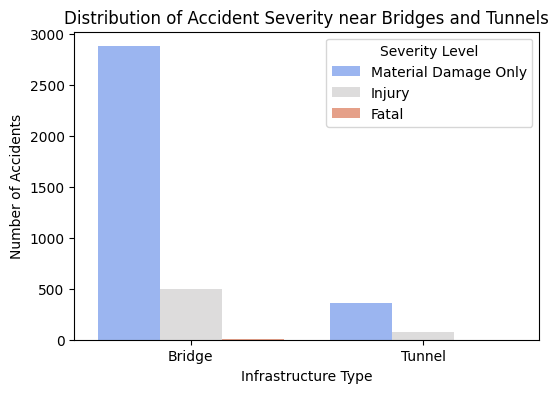

  infrastructureLabel         severityLabel  count  percentage
0              Bridge  Material Damage Only   2875   85.185185
1              Bridge                Injury    493   14.607407
2              Bridge                 Fatal      7    0.207407
3              Tunnel  Material Damage Only    358   82.298851
4              Tunnel                Injury     75   17.241379
5              Tunnel                 Fatal      2    0.459770


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/4187461110.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(percentage=100 * x["count"] / x["count"].sum()))


In [62]:
query = """
PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT 
    ?infrastructureLabel 
    ?severityLabel 
    (COUNT(DISTINCT ?accident) AS ?count)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/categories> {
    ?severity rdfs:label ?severityLabel .
    FILTER(lang(?severityLabel) = "en") # Use 'en' or 'nl'
  }
  
  {
    GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
      ?accident traffic:occursOn ?road ;
                traffic:hasSeverity ?severity .
    }
    GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
      ?road rdf:type ?type .
      FILTER (?type IN (traffic:Bridge, traffic:Tunnel))
      BIND(IF(?type = traffic:Bridge, "Bridge", "Tunnel") AS ?infrastructureLabel)
    }
  }
  UNION
  {
    GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
      ?accident traffic:occursOn ?road ;
                traffic:hasSeverity ?severity .
    }
    GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
      ?road traffic:hasTrafficSign ?sign .
    }
    GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/signs> {
      ?sign traffic:rvvCode "B7"^^xsd:token .
    }
    BIND("Road with Stop Sign" AS ?infrastructureLabel)
  }
}
GROUP BY ?infrastructureLabel ?severityLabel
ORDER BY ?infrastructureLabel DESC(?count)
LIMIT 6
"""
#fallback in case of memoery error, uncomment the lines below and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query2-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())

df = sparql_df(endpoint, query)
df = df.rename(columns={
    "infrastructureLabel": "infrastructureLabel",
    "severityLabel": "severityLabel",
    "count": "count"
})

df["count"] = pd.to_numeric(df["count"], errors="coerce")

plt.figure(figsize=(6,4))
sns.barplot(
    data=df, 
    x="infrastructureLabel", 
    y="count", 
    hue="severityLabel", 
    palette="coolwarm"
)
plt.title("Distribution of Accident Severity near Bridges and Tunnels")
plt.xlabel("Infrastructure Type")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Level")
plt.show()

df_percent = (
    df.groupby("infrastructureLabel")
      .apply(lambda x: x.assign(percentage=100 * x["count"] / x["count"].sum()))
      .reset_index(drop=True)
)
print(df_percent)

"What vehicle types (e.g., Car, Bicycle, Truck) are most frequently involved in accidents on traffic:Residential and traffic:LivingStreet roads?"

/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/433789517.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


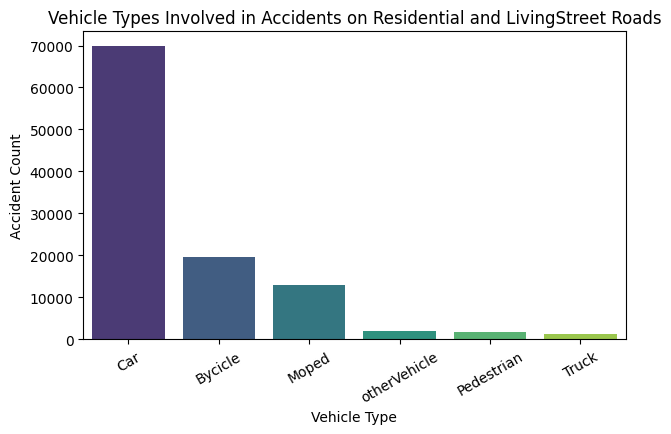

In [63]:
query = """
PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?vehicleClass (COUNT(?accident) AS ?accidentCount)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
    ?road rdf:type ?roadType .
    FILTER(?roadType IN (traffic:Residential, traffic:LivingStreet))
  }
  
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
    ?accident traffic:occursOn ?road ;
              traffic:involvesVehicle ?vehicle .
              
    ?vehicle rdf:type ?vehicleClass .
    
    # Exclude the generic base class from the count
    FILTER(?vehicleClass != traffic:Vehicle) 
  }
}
GROUP BY ?vehicleClass
ORDER BY DESC(?accidentCount)
LIMIT 6
"""
#fallback in case of memoery error, uncomment the lines below and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query3-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())
df = sparql_df(endpoint, query)
df["accidentCount"] = pd.to_numeric(df["accidentCount"], errors="coerce")


df["vehicleLabel"] = df["vehicleClass"].apply(lambda uri: uri.split("/")[-1])
plt.figure(figsize=(7,4))
sns.barplot(
    data=df, 
    x="vehicleLabel", 
    y="accidentCount", 
    palette="viridis"
)
plt.title("Vehicle Types Involved in Accidents on Residential and LivingStreet Roads")
plt.xlabel("Vehicle Type")
plt.ylabel("Accident Count")
plt.xticks(rotation=30)
plt.show()

"What sections of roads with a speed limit over 30 km/h have the most accidents involving pedestrians or cyclists on wet or snowy road surfaces?"

In [ ]:
query = """
PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX inst: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/instance/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?road ?roadName (COUNT(DISTINCT ?accident) AS ?vulnerableUserAccidents)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
    ?accident traffic:occursOn ?road ;
              traffic:involvesVehicle ?vehicle ;
              traffic:hasRoadCondition ?condition .
              
    ?vehicle rdf:type ?vehicleType .
    FILTER(?vehicleType IN (traffic:Pedestrian, traffic:Bycicle)) # Filter for vulnerable users
    FILTER(?condition IN (inst:Wet, inst:Snow)) 
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
    ?road rdfs:label ?roadName ;
          traffic:maxSpeedLimit ?speed .
          
    FILTER(?speed > 30)
  }
}
GROUP BY ?road ?roadName
LIMIT 30
"""
#fallback in case of memoery error, uncomment the lines below and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query4-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())

df = sparql_df(endpoint, query)
df["accidentCount"] = pd.to_numeric(df["accidentCount"], errors="coerce")
df_sorted = df.sort_values("vulnerableUserAccidents", ascending=False).head(30)

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_sorted,
    y="roadName",
    x="vulnerableUserAccidents",
    palette="rocket"
)
plt.title("Accidents Involving Pedestrians or Cyclists on Wet/Snowy Roads (>30 km/h)")
plt.xlabel("Number of Accidents")
plt.ylabel("Road Name")
plt.show()

EndPointInternalError: EndPointInternalError: The endpoint returned the HTTP status code 500. 

Response:
b'Query evaluation error: Insufficient free Heap Memory 228Mb for group by and distinct, threshold:250Mb, reached 2Mb\n'

"Which specific road segments were 'persistent accident hotspots', appearing in the top 20 most dangerous segments for multiple years (2022, 2023, 2024)?"

In [64]:
query = """
PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?road ?roadName (COUNT(?accident) AS ?totalAccidents) (COUNT(DISTINCT ?year) AS ?yearsWithAccidents)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
    ?accident traffic:occursOn ?road ;
              traffic:year ?year .
    FILTER(?year IN (2022, 2023, 2024))
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/roads> {
    ?road rdfs:label ?roadName .
  }
}
GROUP BY ?road ?roadName
HAVING (COUNT(DISTINCT ?year) >= 2) 
LIMIT 30
"""

#fallback in case of memoery error, uncomment the lines below and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query5-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())

df = sparql_df(endpoint, query)
df["totalAccidents"] = pd.to_numeric(df["totalAccidents"], errors="coerce")
df["yearsWithAccidents"] = pd.to_numeric(df["yearsWithAccidents"], errors="coerce")


df_persistent = df[df["yearsWithAccidents"] == 3]

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_persistent.sort_values("totalAccidents", ascending=False).head(30),
    y="roadName",
    x="totalAccidents",
    palette="flare"
)
plt.title("Persistent Accident Hotspots (Top 20 in 2022, 2023, and 2024)")
plt.xlabel("Total Accidents (2022–2024)")
plt.ylabel("Road Name")
plt.show()


EndPointInternalError: EndPointInternalError: The endpoint returned the HTTP status code 500. 

Response:
b'Query evaluation error: Insufficient free Heap Memory 249Mb for group by and distinct, threshold:250Mb, reached 14Mb\n'

"What are the most common types of traffic signs (e.g., speed limits, priority signs) present on road segments where accidents occur?"

In [60]:
query = """
PREFIX traffic: <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX rdf:     <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?rvvCode ?signLabel (COUNT(DISTINCT ?accident) AS ?accidentCount)
WHERE {
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/accidents> {
    ?accident rdf:type traffic:Accident ;
              traffic:occursOn ?road .
  }
  GRAPH <http://www.semanticweb.org/nicol/ontologies/2025/9/traffic/graph/signs> {
    ?road traffic:hasTrafficSign ?sign .
    
    # Also get the sign's details from this graph
    ?sign traffic:rvvCode ?rvvCode ;
          rdfs:label ?signLabel .
  }
}
GROUP BY ?rvvCode ?signLabel
ORDER BY DESC(?accidentCount)
LIMIT 25
"""
df = sparql_df(endpoint, query)
df["accidentCount"] = pd.to_numeric(df["accidentCount"], errors="coerce")

#fallback in case of memory error, uncomment the lines below, and comment out the sparql_df() function
#file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query6-result.csv"
#df = pd.read_csv(file_path)
#print(df.head())

plt.figure(figsize=(8,5))
sns.barplot(
    data=df.sort_values("accidentCount", ascending=False).head(25),
    y="signLabel",
    x="accidentCount",
    palette="crest"
)
plt.title("Most Common Traffic Signs on Road Segments with Accidents")
plt.xlabel("Number of Accidents (on segments containing sign)")
plt.ylabel("Traffic Sign Type")
plt.show()

KeyError: 'accidentCount'